## Selección de variables

### Análisis descriptivo
Con el objetivo de identificar las variables con mayor potencial predictivo, se analiza la relación entre las variables explicativas y la variable respuesta, que indica si el bateador realizó o no un swing. Para ello, se llevan a cabo análisis bivariados que permiten explorar posibles asociaciones, detectar patrones de comportamiento y evaluar la relevancia de las distintas variables para la construcción de los modelos.

Para poder llevar a cabo la selección, se crea la variable respuesta `swing` siguiendo los criterios descriptos en la notebook "Construcción_variable_rta.ipynb".

In [1]:
# Cargamos los paquetes necesarios ACORDARNOS DE HACER EL AMBIENTE VIRTUAL
import matplotlib.pyplot as plt 
import polars as pl
import seaborn as sns
import numpy as np
import pyprojroot
from plotnine import *
import pandas as pd

In [2]:
# Definir la ruta raiz del proyecto
ROOT = pyprojroot.here()

# Cargamos los datos
datos_entrenamiento = pl.read_parquet(ROOT / "datos" / "temporada1.parquet")
datos_entrenamiento_imputados = pl.read_parquet(ROOT / "datos" / "temporada1_imputada.parquet")

### Proporción de swings según el tipo de lanzamiento

El tipo de lanzamiento puede influir en la decisión del bateador de realizar un swing, ya que cada categoría presenta características particulares de velocidad y movimiento. Analizar la proporción de swings para cada tipo de lanzamiento permite identificar posibles diferencias en el comportamiento de los bateadores frente a las distintas alternativas ofrecidas por el pitcher.

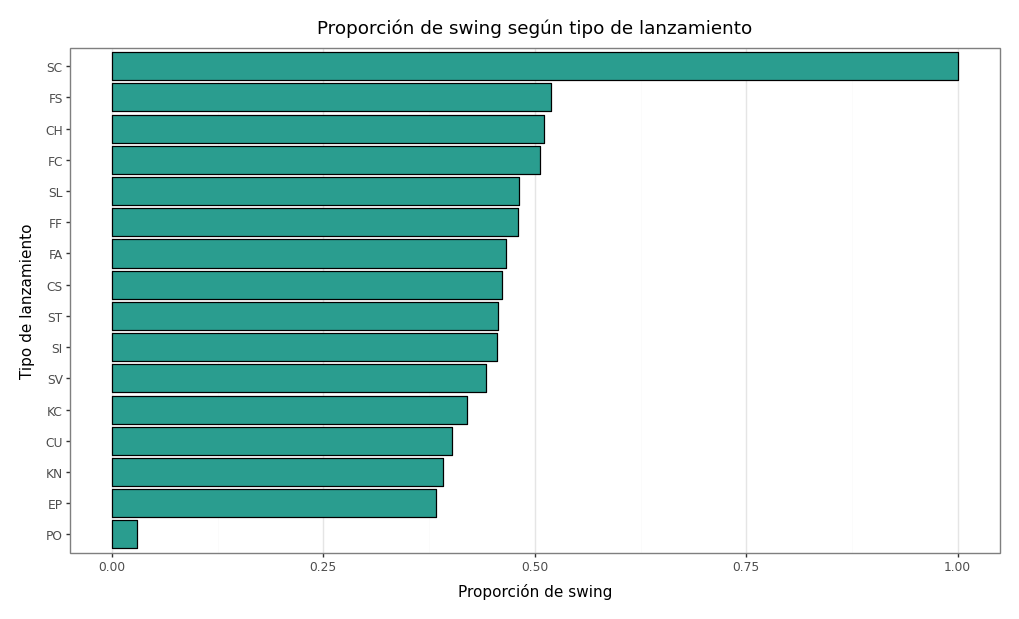

In [5]:
# Se calcula la proporción de swing según tipo de lanzamiento
swing_pitch_type = (
    datos_entrenamiento
    .filter(pl.col("pitch_type").is_not_null())
    .group_by("pitch_type")
    .agg(
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(
        swing_pitch_type,
        aes(x="pitch_type", y="proporcion_swing")
    )
    + geom_col(fill="#2A9D8F", color = "black")
    + coord_flip()
    + scale_x_discrete(
        limits=swing_pitch_type["pitch_type"].tolist()[::-1]
    )
    + labs(
        title="Proporción de swing según tipo de lanzamiento",
        x="Tipo de lanzamiento",
        y="Proporción de swing"
    )
    + theme_bw()
    + theme(
        figure_size=(10, 6),
        panel_grid_major_y=element_blank(),
        panel_grid_minor_y=element_blank()
    )
)

In [6]:
# Cantidad de swings por tipo de lanzamiento
datos_entrenamiento["pitch_type"].value_counts(sort = True)

pitch_type,count
str,u32
"""FF""",251235
"""SL""",125903
"""SI""",108897
"""CH""",80152
"""CU""",54051
…,…
"""CS""",156
"""EP""",128
"""KN""",69


La proporción de swings resulta similar entre la mayoría de los tipos de lanzamiento. Aunque algunas categorías presentan valores similares, en otras se observan diferencias marcadas que permitan distinguir entre los distintos tipos de lanzamiento en función de esta característica. Por otro lado, las categorías `SC` y `PO` muestran proporciones extremas; sin embargo, estos resultados deberían interpretarse con cautela debido a que el primer lanzamiento tiene 1 sola observación y el segundo sólo tiene 34. En conjunto, la evidencia sugiere que el tipo de lanzamiento, considerado de manera aislada, parece presentar una asociación con la realización de un swing. CAMBIAR!!!

#### Proporción de swing según posición del bateador

Evaluar la proporción de swings permite identificar si existen diferencias de comportamiento según la ubicación del bateador, ya que esta característica puede influir en la estrategia de juego y en la decisión de realizar un swing frente a un lanzamiento.

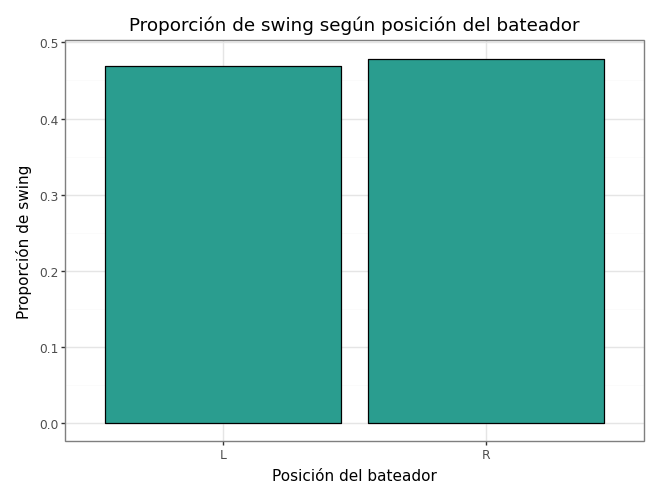

In [7]:
# Se calcula la proporción de swing según posición del bateador
swing_stand = (
    datos_entrenamiento
    .filter(pl.col("stand").is_not_null())
    .group_by("stand")
    .agg(
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(
        swing_stand,
        aes(x="stand", y="proporcion_swing")
    )
    + geom_col(fill="#2A9D8F", color = "black")
    + labs(
        title="Proporción de swing según posición del bateador",
        x="Posición del bateador",
        y="Proporción de swing"
    )
    + theme_bw()
)

Se observa una distribución muy similar entre bateadores derechos e izquierdos, con una proporción de swings aproximada de 0.5 en ambos grupos. La ausencia de diferencias marcadas sugiere que la posición del bateador no tendría una influencia importante sobre la ocurrencia de un swing.

#### Proporción de swing según mano del pitcher

La mano del pitcher es una característica relevante a analizar, ya que puede influir en la estrategia del bateador y en la forma en que enfrenta un lanzamiento. Por este motivo, estudiar la proporción de swings permite observar si existen diferencias de comportamiento frente a lanzadores derechos o zurdos.

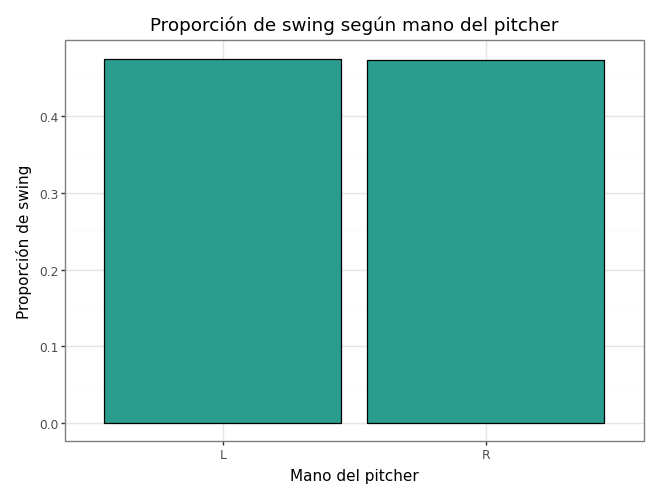

In [7]:
# Se calcula la proporción de swing según mano del pitcher
swing_pthrows = (
    datos_entrenamiento
    .filter(pl.col("p_throws").is_not_null())
    .group_by("p_throws")
    .agg(
        pl.col("swing").mean().alias("proporcion_swing")
    )
    .sort("proporcion_swing", descending=True)
    .to_pandas()
)
# Se arma el gráfico
(
    ggplot(
        swing_pthrows,
        aes(x="p_throws", y="proporcion_swing")
    )
    + geom_col(fill="#2A9D8F", color = "black")
    + labs(
        title="Proporción de swing según mano del pitcher",
        x="Mano del pitcher",
        y="Proporción de swing"
    )
    + theme_bw()
)

De manera similar a lo observado para la posición del bateador, la distribución de la proporción de swings según la mano del pitcher es prácticamente la misma entre categorías. La ausencia de diferencias permite suponer que esta variable no muestra una relación evidente con la ocurrencia de un swing.

#### Relación entre variables cuantitativas contínuas y la intención del swing



Con el objetivo de identificar posibles relaciones entre las variables cuantitativas continuas y la intención de swing, se construye un panel de boxplots que permite comparar la distribución de cada predictor en función de la variable respuesta. Esta visualización facilita la detección de diferencias entre grupos y la identificación de variables relevantes para el modelo a proponer.

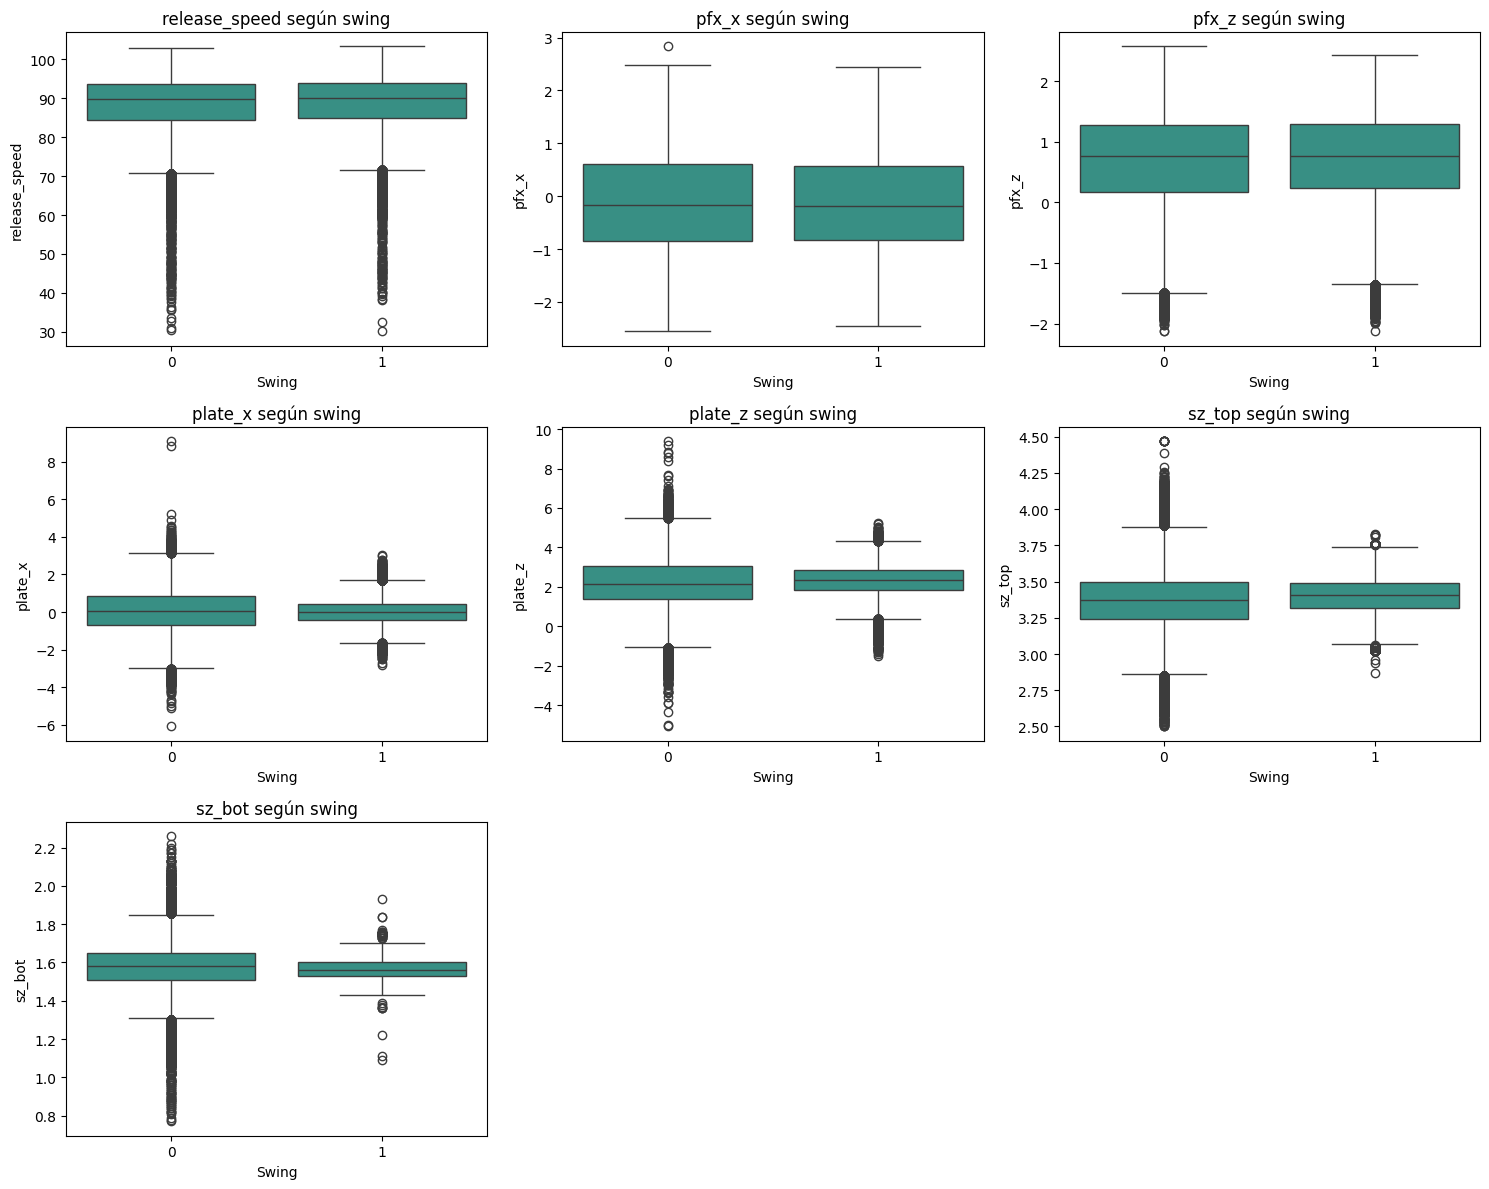

In [9]:
# Se seleccionan las variables cuantitativas continuas del conjunto de datos
variables_continuas = [
    "release_speed",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot"
]

# Se arma el panel de gráficos
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, variable in enumerate(variables_continuas):
    sns.boxplot(
        data=datos_entrenamiento,
        x="swing",
        y=variable,
        color = "#2A9D8F",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{variable} según swing")
    axes[i].set_xlabel("Swing")
    axes[i].set_ylabel(variable)

# Eliminar espacios vacíos si quedan gráficos sin usar
for j in range(len(variables_continuas), len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

#cambiar color

A partir del panel de boxplots se observa que las variables `release_speed`, `pfx_x` y `pfx_z` presentan distribuciones muy similares entre los grupos con y sin swing, lo que sugiere una capacidad limitada para discriminar entre ambas categorías de la variable respuesta.

Por otro lado, las variables `plate_x`, `plate_z`, `sz_top` y `sz_bot` muestran algunas diferencias en sus medianas y niveles de dispersión. En el caso de `plate_x`, se observa una menor dispersión para los lanzamientos en los que el bateador realiza swing, mientras que para `plate_z` se aprecia un leve desplazamiento de la distribución hacia valores más altos cuando ocurre un swing.

Asimismo, las variables `sz_top` y `sz_bot`, que representan los límites superior e inferior de la zona de strike respectivamente, muestran cambios tanto en la dispersión como en la ubicación de sus distribuciones entre los grupos. En particular, para los lanzamientos con swing se observan distribuciones más concentradas y una menor presencia de valores extremos.

En conjunto, los resultados indican que las variables relacionadas con la ubicación espacial de la pelota y con la definición de la zona de strike presentan una mayor capacidad para diferenciar entre situaciones con y sin swing, por lo que podrían ser consideradas como variables relevantes.

Luego, se analiza la relación entre la altura de la zona de strike (variable creada) y la intención de swing por parte del bateador.

In [ ]:
df_plot = datos_entrenamiento.select(
    ["altura_zona", "swing"]
).to_pandas()


(
    ggplot(
        df_plot,
        aes(x="factor(swing)", y="altura_zona")
    )
    + geom_boxplot(
        fill="#2A9D8F",
        color="black"
    )
    + labs(
        x="Swing",
        y="Altura de la zona de strike",
        title="Distribución de la altura de la zona según swing"
    )
    + theme_bw()
)

#### Relación entre las variables cuantitativas discretas y la intención de swing
Para las variables cuantitativas discretas se utilizan gráficos de barras para analizar su relación con la intención de swing.

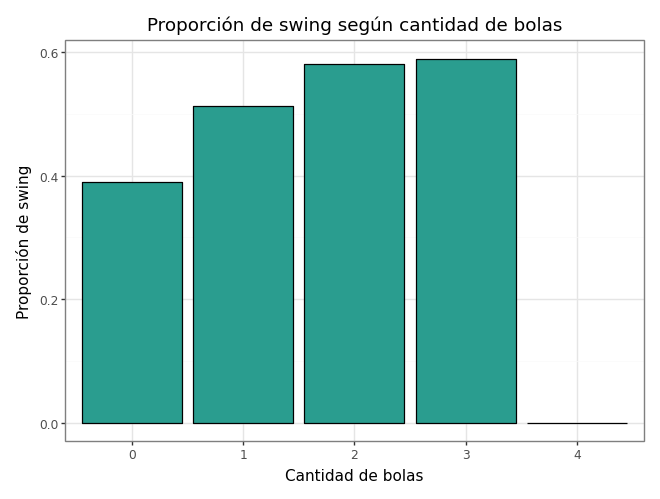

In [7]:
datos_pd = datos_entrenamiento.to_pandas()
# Se calcula la proporción de swing por cantidad de bolas
balls_swing = (
    datos_pd
    .groupby("balls", as_index=False)
    ["swing"]
    .mean()
)

# Se arma el gráfico
(
    ggplot(balls_swing, aes(x="factor(balls)", y="swing"))
    + geom_col(
        fill="#2A9D8F",
        color="black"
    )
    + labs(
        title="Proporción de swing según cantidad de bolas",
        x="Cantidad de bolas",
        y="Proporción de swing"
    )
    + theme_bw()
)

Se observa una tendencia creciente entre la proporción de swings y la cantidad de bolas, es decir que la proporción de swings aumenta a medida que aumenta la cantidad de bolas. Sin embargo, el caso de 4 bolas presenta un comportamiento atípico, con una proporción de swings cercana a cero. Esto se debe a que, al alcanzar cuatro bolas, el bateador obtiene la base por bolas y el turno termina, por lo que ya no existe un lanzamiento posterior sobre el cual pueda decidir realizar un swing.

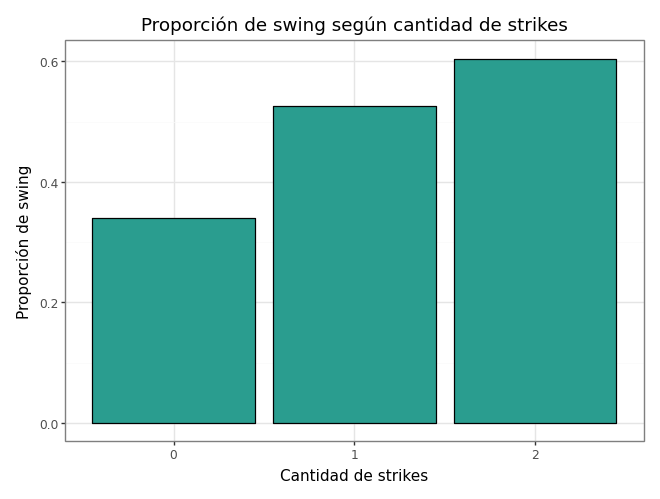

In [8]:
# Se calcula la proporción de swing según la cantidad de strikes
strikes_swing = (
    datos_pd
    .groupby("strikes", as_index=False)
    ["swing"]
    .mean()
)

# Se arma el gráfico
(
    ggplot(strikes_swing, aes(x="factor(strikes)", y="swing"))
    + geom_col(
        fill="#2A9D8F",
        color="black"
    )
    + labs(
        title="Proporción de swing según cantidad de strikes",
        x="Cantidad de strikes",
        y="Proporción de swing"
    )
    + theme_bw()
)

Se observa que la proporción de swings aumenta a medida que incrementa la cantidad de strikes en la cuenta. Esto indica que, a medida que el bateador se encuentra más cerca de quedar eliminado, aumenta su intención de realizar un swing para intentar continuar en el turno.

### Métodos de selección de variables

Si bien el análisis descriptivo realizado previamente permite identificar variables que podrían resultar relevantes para explicar la ocurrencia de un swing (como balls, strike, plate_x, plate_z, ...), las conclusiones obtenidas en esta etapa son principalmente exploratorias. Por este motivo, se aplican métodos de selección de variables con el objetivo de evaluar de manera más objetiva la contribución de cada predictor y determinar cuáles aportan información relevante para la construcción de los modelos predictivos. 

#### Preparación de los datos

Con el objetivo de aplicar métodos de selección basados en penalización, las variables categóricas se transforman mediante One-Hot Encoding (Creación de variables dummies). 

Debido a que el método LASSO depende de la escala de los predictores, las variables numéricas fueron estandarizadas mediante la transformación Z-score. Luego de la transformación, las variables presentan medias aproximadamente iguales a cero y desvíos estándar cercanos a uno, asegurando una contribución comparable de cada predictor dentro del modelo penalizado.

In [3]:

variables_cuantitativas = [
    "release_speed",
    "balls",
    "strikes",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot",
    "altura_zona"
]

variables_categoricas = [
    "pitch_type",
    "stand",
    "p_throws"
]

predictores = variables_cuantitativas + variables_categoricas

In [4]:
X = datos_entrenamiento_imputados.select(predictores).to_pandas()
# Convertimos a dummies las variables categoricas
X = pd.get_dummies(
    X,
    columns=variables_categoricas,
    drop_first=True
)

In [5]:
from sklearn.preprocessing import StandardScaler
# INSTALAR: pip install scikit-learn
#ESTANDARIZACIÓN
scaler = StandardScaler()

X[variables_cuantitativas] = scaler.fit_transform(
    X[variables_cuantitativas]
)

X[variables_cuantitativas].describe()

,release_speed,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot,altura_zona
count,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05,7.098520e+05
mean,1.120129e-15,3.203114e-17,-6.918726e-17,2.562491e-18,-4.740608e-17,-1.473432e-17,1.213980e-16,-3.798893e-16,-3.089403e-16,2.142883e-15
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-9.712564e+00,-9.124019e-01,-1.080878e+00,-2.839462e+00,-3.734272e+00,-7.262949e+00,-7.461646e+00,-5.418898e+00,-8.967529e+00,-7.066631e+00
25%,-7.024936e-01,-9.124019e-01,-1.080878e+00,-8.394877e-01,-6.134857e-01,-6.781097e-01,-6.451279e-01,-5.588194e-01,-7.122065e-01,-3.461159e-01
50%,1.737156e-01,1.201386e-01,1.262855e-01,-7.649187e-02,1.365744e-01,-4.257199e-03,5.031816e-03,1.094422e-01,-1.544150e-01,1.987915e-01
75%,8.019400e-01,1.152679e+00,1.333449e+00,8.021094e-01,8.330589e-01,6.695954e-01,6.551916e-01,5.954496e-01,5.149362e-01,5.620634e-01
max,2.405568e+00,3.217760e+00,1.333449e+00,3.403231e+00,2.574270e+00,1.071827e+01,7.227900e+00,6.549045e+00,7.654675e+00,7.555034e+00


#### Regresión LASSO

Dado que el análisis exploratorio permitió identificar múltiples variables potencialmente asociadas con la decisión de realizar un swing, se implementa un método automático de selección de variables que permita evaluar su contribución conjunta dentro de un modelo predictivo. Para ello, se utiliza una regresión logística con regularización LASSO, la cual permite controlar la complejidad del modelo mediante la penalización de los coeficientes.

La principal ventaja de este enfoque es que, además de estimar la relación entre los predictores y la variable respuesta, realiza una selección implícita de variables al llevar algunos coeficientes exactamente a cero. Por lo tanto, las variables con coeficientes no nulos son consideradas relevantes para explicar la probabilidad de swing y serán utilizadas posteriormente en la construcción de los modelos predictivos.


In [8]:
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=1000
)

y = datos_entrenamiento_imputados["swing"]

lasso.fit(X, y)

C:\Users\vicky\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
C:\Users\vicky\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the

Se obtienen los coeficientes del modelo de regresión LASSO.

In [10]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lasso.coef_[0]
})

coeficientes

,Variable,Coeficiente
0,release_speed,0.088775
1,balls,0.174215
2,strikes,0.413174
3,pfx_x,0.008307
4,pfx_z,0.002147
5,plate_x,-0.045449
6,plate_z,0.161652
7,sz_top,-0.356443
8,sz_bot,-0.525173
9,altura_zona,1.327564


Luego, se descartan aquellos coeficientes nulos.

In [11]:
variables_seleccionadas = coeficientes[
    coeficientes["Coeficiente"] != 0
]

variables_seleccionadas

,Variable,Coeficiente
0,release_speed,0.088775
1,balls,0.174215
2,strikes,0.413174
3,pfx_x,0.008307
4,pfx_z,0.002147
5,plate_x,-0.045449
6,plate_z,0.161652
7,sz_top,-0.356443
8,sz_bot,-0.525173
9,altura_zona,1.327564


Se contruye una tabla en la cual se ordenan las variables que deben ser incorporadas en el modelo según su importancia.

In [12]:
variables_seleccionadas = (
    variables_seleccionadas
    .assign(
        importancia=lambda x: abs(x["Coeficiente"])
    )
    .sort_values(
        "importancia",
        ascending=False
    )
)

variables_seleccionadas

,Variable,Coeficiente,importancia
9,altura_zona,1.327564,1.327564
19,pitch_type_PO,-1.318020,1.318020
8,sz_bot,-0.525173,0.525173
2,strikes,0.413174,0.413174
7,sz_top,-0.356443,0.356443
15,pitch_type_FF,-0.329226,0.329226
21,pitch_type_SI,-0.286314,0.286314
11,pitch_type_CU,-0.279368,0.279368
17,pitch_type_KC,-0.257090,0.257090
23,pitch_type_ST,-0.208155,0.208155


Dado que las categorías de las variables cualitativas aparecen como dummies, se vuelven a agrupar para poder trabajar con la variable original. Para esto, se construye una función que te devuelve las variables nuevamente agrupadas.

In [ ]:
# para volver a la variable principal
def variable_original(nombre):
    if nombre.startswith("pitch_type_"):
        return "pitch_type"
    elif nombre.startswith("stand_"):
        return "stand"
    elif nombre.startswith("p_throws_"):
        return "p_throws"
    else:
        return nombre

In [28]:
variables_seleccionadas["Variable_original"] = (
    variables_seleccionadas["Variable"]
    .apply(variable_original)
)

lasso_resumen = (
    variables_seleccionadas
    .groupby("Variable_original")
    .agg(
        Coeficiente=("Coeficiente", lambda x: x.abs().max())
    )
    .reset_index()
)
lasso_resumen

,Variable_original,Coeficiente
0,altura_zona,1.327564
1,balls,0.174215
2,p_throws,0.009898
3,pfx_x,0.008307
4,pfx_z,0.002147
5,pitch_type,1.318020
6,plate_x,0.045449
7,plate_z,0.161652
8,release_speed,0.088775
9,stand,0.047307


En conclusión, se puede ver que las variables con coeficientes no nulos son las más relevantes para ser potencialmente predictoras en el modelo. MEJORAR

#### Selección hacia adelante

Si bien el modelo LASSO permite identificar predictores relevantes mediante la penalización de sus coeficientes, la decisión final sobre el conjunto de variables puede depender del valor del parámetro de regularización y no necesariamente conduce al subconjunto que optimiza el desempeño predictivo del modelo.

Por este motivo, se implementa un procedimiento de **selección secuencial hacia adelante (Forward Selection)**. Este método comienza ajustando un modelo sin predictores e incorpora las variables de forma iterativa, agregando en cada paso aquella que produce la mayor mejora en el desempeño del modelo según el criterio de evaluación establecido. El proceso continúa hasta alcanzar un número prefijado de variables.

Con el fin de determinar el tamaño más adecuado del subconjunto de predictores, se evalúan distintos valores para el número de variables seleccionadas y se compara el desempeño de los modelos obtenidos mediante validación cruzada utilizando el área bajo la curva ROC (AUC). Finalmente, se selecciona el subconjunto que presenta el mejor equilibrio entre capacidad predictiva y complejidad del modelo.


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

resultados = []

for n in range(4, 13):

    sfs = SequentialFeatureSelector(
        estimator=modelo,
        n_features_to_select=n,
        direction="forward",
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )

    sfs.fit(X, y)

    variables = X.columns[sfs.get_support()]

    auc = cross_val_score(
        modelo,
        X[variables],
        y,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    ).mean()

    resultados.append({
        "n_variables": n,
        "AUC": auc,
        "Variables": list(variables)
    })

resultados = pd.DataFrame(resultados)

resultados

# TARDA MUCHO EN CORRER, HABRÍA QUE PROBAR CON OTRO MÉTODO

KeyboardInterrupt: 

In [ ]:
resultados.sort_values("AUC", ascending=False)